# Moods — pipeline Google Takeout → humeurs

Ce notebook prend un export **Google Takeout** de ta bibliothèque YouTube / YouTube Music et
en sort une carte des humeurs, sans jamais stocker d'audio.

**Pourquoi Takeout et pas l'API YouTube ?** L'API YouTube Data v3 ne voit pas les contenus
propres à YouTube Music : ni les *Liked Songs*, ni les playlists YT Music, ni la musique
uploadée. Elle ne connaît que les playlists YouTube classiques. Takeout, lui, exporte tout —
officiellement, gratuitement, sans reverse-engineering ni auth par cookie.

**Comment obtenir ton export :** [takeout.google.com](https://takeout.google.com) →
décocher tout → cocher **YouTube and YouTube Music** → dans « contenus multiples », ne garder
que `music-library-songs` et `playlists` → exporter. Tu obtiens un zip contenant des CSV.

### Le pipeline

```
Takeout CSV  ──►  normalisation  ──►  recherche iTunes  ──►  preview 30s
(artiste/titre)    (titres YouTube)    (API publique)          │
                                                               ▼
       carte des humeurs  ◄──  features (~400 o/morceau)  ◄──  Essentia
```

Aucun abonnement n'est nécessaire : ni Spotify Premium (dont l'API est de toute façon fermée
depuis mars 2026 sans Premium), ni YouTube Premium — les previews iTunes sont publiques.
YouTube Premium ne sert qu'au confort d'écoute côté lecture, et ses téléchargements offline
sont verrouillés DRM, donc inutilisables pour l'analyse.

## 1. Setup

In [1]:
# pip install essentia-tensorflow pandas numpy matplotlib
# apt-get install -y ffmpeg

import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import essentia.standard as es

import takeout_moods as tm   # le module livré à côté de ce notebook

%matplotlib inline

TAKEOUT_PATH = "sample_takeout"   # <-- ton dossier/zip Takeout ici
PALETTE = {"Happy": "#2a9d8f", "Sad": "#e76f51", "music-library-songs": "#6a7fdb"}

## 2. Lecture de l'export

Le schéma des CSV Takeout **change** d'une version à l'autre et d'un fichier à l'autre :
`music-library-songs.csv` porte `Title/Album/Artist`, les playlists YouTube Music portent
`Song Title/Artist Names/Video ID`, et les playlists YouTube classiques ne contiennent souvent
qu'un `Video ID` + le titre de la vidéo.

Plutôt que de coder en dur un schéma, `load_takeout()` **détecte les colonnes** par
correspondance floue sur les en-têtes, et te dit ce qu'il a trouvé — pour que tu puisses
vérifier au lieu de faire confiance.

In [2]:
df = tm.load_takeout(TAKEOUT_PATH)
print(json.dumps(df.attrs["detected_columns"], indent=1, ensure_ascii=False))

{
 "music-library-songs.csv": {
  "title": "Title",
  "artist": "Artist",
  "album": "Album"
 },
 "Happy.csv": {
  "title": "Song Title",
  "artist": "Artist Names",
  "video_id": "Video ID",
  "album": "Album Title"
 },
 "Sad.csv": {
  "title": "Video Title",
  "video_id": "Video ID"
 }
}


Deux nettoyages font l'essentiel du taux de matching sur des données YouTube :

- **les titres** sont pollués (`(Official Music Video)`, `[Official Audio]`, `(2011 Remaster)`,
  `Official MV`…) — invisibles côté iTunes, ils font échouer la recherche ;
- **les artistes** arrivent en `Artist - Topic` (les chaînes auto-générées de YouTube Music) ;
- quand tout est dans un seul champ (`Adele - Someone Like You (Official Music Video)`),
  il faut le scinder en artiste + titre.

Attention aux faux amis en écrivant ces règles : découper l'artiste sur `&`/`and`/`,` casse
« Earth, Wind & Fire » ou « Simon & Garfunkel », et un `ft` sans limite de mot transforme
« Daft Punk » en « Da ». Le module ne coupe que sur des marqueurs *explicites*
(`feat.`, `ft.`, `featuring`, `with`).

In [3]:
df[["playlist", "artist", "title", "video_id"]]

playlist,artist,title,video_id
music-library-songs,BTS (방탄소년단),Dynamite,
music-library-songs,Queen,Bohemian Rhapsody,
music-library-songs,Nonexistent Bedroom Band,Kerkelakerkela Obscure Demo Tape,
music-library-songs,Billie Eilish,when the party's over,
Happy,Mark Ronson - Topic,Uptown Funk (feat. Bruno Mars),uSD4vsh1zDA
Happy,ABBA - Topic,Dancing Queen,xFrGuyw1V8s
Happy,"Earth, Wind & Fire - Topic",September,Gs069dndIYk
Happy,Daft Punk - Topic,Get Lucky (feat. Pharrell Williams),5NV6Rdv1a3I
Happy,Stromae - Topic,Alors On Danse,VHoT4N43jK8
Happy,Lizzo - Topic,Good as Hell,SmbmeOgWsqE


## 3. Matching iTunes — la question qui décide de tout

Pour chaque morceau on interroge l'API iTunes Search et on **score** le meilleur candidat
(similarité entre `artiste + titre` normalisés). Trois issues :

| statut | sens |
|---|---|
| `matched` | score ≥ seuil, preview disponible |
| `low_confidence` | trouvé mais douteux — à relire à la main |
| `no_result` | rien d'exploitable |

Le score n'est pas cosmétique : c'est lui qui repère les cas où iTunes renvoie **le bon titre
mais le mauvais enregistrement** (un remix, une version live).

In [4]:
matched = tm.match_library(df, threshold=0.72, pause=0.4)
matched[["playlist", "artist", "title", "status", "score", "itunes_artist", "itunes_track"]]

playlist,artist,title,status,score,itunes_artist,itunes_track
music-library-songs,BTS (방탄소년단),Dynamite,matched,0.960,BTS,Dynamite
music-library-songs,Queen,Bohemian Rhapsody,matched,1.000,Queen,Bohemian Rhapsody
music-library-songs,Nonexistent Bedroom Band,Kerkelakerkela Obscure Demo Tape,no_result,0.000,NaN,NaN
music-library-songs,Billie Eilish,when the party's over,matched,1.000,Billie Eilish,when the party's over
Happy,Mark Ronson - Topic,Uptown Funk (feat. Bruno Mars),matched,1.000,Mark Ronson,Uptown Funk (feat. Bruno Mars)
Happy,ABBA - Topic,Dancing Queen,matched,1.000,ABBA,Dancing Queen
Happy,"Earth, Wind & Fire - Topic",September,matched,1.000,"Earth, Wind & Fire",September
Happy,Daft Punk - Topic,Get Lucky (feat. Pharrell Williams),low_confidence,0.704,Daft Punk,Get Lucky (feat. Pharrell Williams & Nile Rodgers) [Daft Punk Remix]
Happy,Stromae - Topic,Alors On Danse,matched,1.000,Stromae,Alors on danse
Happy,Lizzo - Topic,Good as Hell,matched,1.000,Lizzo,Good as Hell


In [5]:
tm.coverage_report(matched)

,tracks,share
status,,
matched,14,87.5
no_result,1,6.2
low_confidence,1,6.2


### Les cas à relire

C'est là que se cache le vrai coût du pipeline. Sur cet échantillon :

- **Daft Punk — Get Lucky** est rattrapé par le score : iTunes a renvoyé un *Daft Punk Remix*,
  soit le bon titre mais pas l'enregistrement voulu → `low_confidence` (0.70).
- **Nirvana — The Man Who Sold The World (MTV Unplugged)** est passé **au-dessus** du seuil
  (0.78) alors qu'iTunes a servi une version *Rehearsal*. Le seuil n'attrape pas tout : les
  versions live et les remixes sont la faiblesse systématique de ce matching, parce que le
  titre est presque identique alors que l'audio, lui, ne l'est pas.

Conséquence pratique : les features d'un morceau `low_confidence` décrivent peut-être un autre
enregistrement. Garde la colonne `score` dans ta base — c'est ce qui te permettra plus tard de
trier le douteux du sûr.

In [6]:
matched[matched["status"] == "low_confidence"][
    ["artist", "title", "score", "itunes_artist", "itunes_track"]]

artist,title,score,itunes_artist,itunes_track
Daft Punk - Topic,Get Lucky (feat. Pharrell Williams),0.704,Daft Punk,Get Lucky (feat. Pharrell Williams & Nile Rodgers) [Daft Punk Remix]


In [7]:
matched[matched["status"] == "no_result"][["playlist", "artist", "title"]]

playlist,artist,title
music-library-songs,Nonexistent Bedroom Band,Kerkelakerkela Obscure Demo Tape


## 4. Features Essentia sur les morceaux appariés

Même pipeline que le notebook v2 : un embedding MusiCNN par morceau, réutilisé par toutes les
têtes. Ici valence/arousal + trois classifieurs, pour rester lisible.

In [8]:
import urllib.request

MODELS = "models"
os.makedirs(MODELS, exist_ok=True)
BINARY_HEADS = [("mood_happy", "happy"), ("mood_sad", "sad"), ("danceability", "danceable")]
HEAD_VERSION = {"deam": 2}

# embedding + une tête par feature (les .json portent les noms de nœuds et les classes)
_emb = "msd-musicnn-1.pb"
if not os.path.exists(os.path.join(MODELS, _emb)):
    urllib.request.urlretrieve(
        f"https://essentia.upf.edu/models/feature-extractors/musicnn/{_emb}",
        os.path.join(MODELS, _emb))
for _name in [n for n, _ in BINARY_HEADS] + ["deam"]:
    _v = HEAD_VERSION.get(_name, 1)
    for _ext in ("pb", "json"):
        _f = f"{_name}-msd-musicnn-{_v}.{_ext}"
        if not os.path.exists(os.path.join(MODELS, _f)):
            urllib.request.urlretrieve(
                f"https://essentia.upf.edu/models/classification-heads/{_name}/{_f}",
                os.path.join(MODELS, _f))

def load_head(name, version=1):
    meta = json.load(open(os.path.join(MODELS, f"{name}-msd-musicnn-{version}.json")))
    s = meta["schema"]
    algo = es.TensorflowPredict2D(
        graphFilename=os.path.join(MODELS, f"{name}-msd-musicnn-{version}.pb"),
        input=s["inputs"][0]["name"], output=s["outputs"][0]["name"])
    return algo, meta["classes"]

embedding_model = es.TensorflowPredictMusiCNN(
    graphFilename=os.path.join(MODELS, "msd-musicnn-1.pb"), output="model/dense/BiasAdd")
deam = load_head("deam", 2)
heads = {n: load_head(n) for n, _ in BINARY_HEADS}

usable = matched[matched["status"].isin(["matched", "low_confidence"])].copy()

rows = []
for rec in usable.to_dict("records"):
    wav = tm.fetch_preview(rec["preview_url"], rec["itunes_track_id"], "audio")
    emb = embedding_model(es.MonoLoader(filename=wav, sampleRate=16000)())
    v, a = deam[0](emb).mean(axis=0)
    rec["valence"], rec["arousal"] = float(v), float(a)
    for name, positive in BINARY_HEADS:
        algo, classes = heads[name]
        rec[positive] = float(algo(emb).mean(axis=0)[classes.index(positive)])
    rows.append(rec)

feat = pd.DataFrame(rows)
feat[["playlist", "itunes_artist", "itunes_track", "valence", "arousal",
      "happy", "sad", "danceable"]].round(3)

playlist,itunes_artist,itunes_track,valence,arousal,happy,sad,danceable
music-library-songs,BTS,Dynamite,5.909,6.165,0.735,0.275,0.998
music-library-songs,Queen,Bohemian Rhapsody,4.007,3.814,0.185,0.960,0.084
music-library-songs,Billie Eilish,when the party's over,4.353,3.409,0.071,0.840,0.552
Happy,Mark Ronson,Uptown Funk (feat. Bruno Mars),6.847,6.829,0.876,0.033,0.997
Happy,ABBA,Dancing Queen,5.727,6.196,0.991,0.092,0.995
Happy,"Earth, Wind & Fire",September,6.073,6.508,0.962,0.012,1.000
Happy,Daft Punk,Get Lucky (feat. Pharrell Williams & Nile Rodgers) [Daft Punk Remix],6.251,6.667,0.919,0.002,0.999
Happy,Stromae,Alors on danse,6.192,5.814,0.751,0.091,0.875
Happy,Lizzo,Good as Hell,6.215,5.693,0.941,0.273,0.970
Sad,Adele,Someone Like You,3.994,4.223,0.088,0.990,0.152


## 5. La carte des humeurs

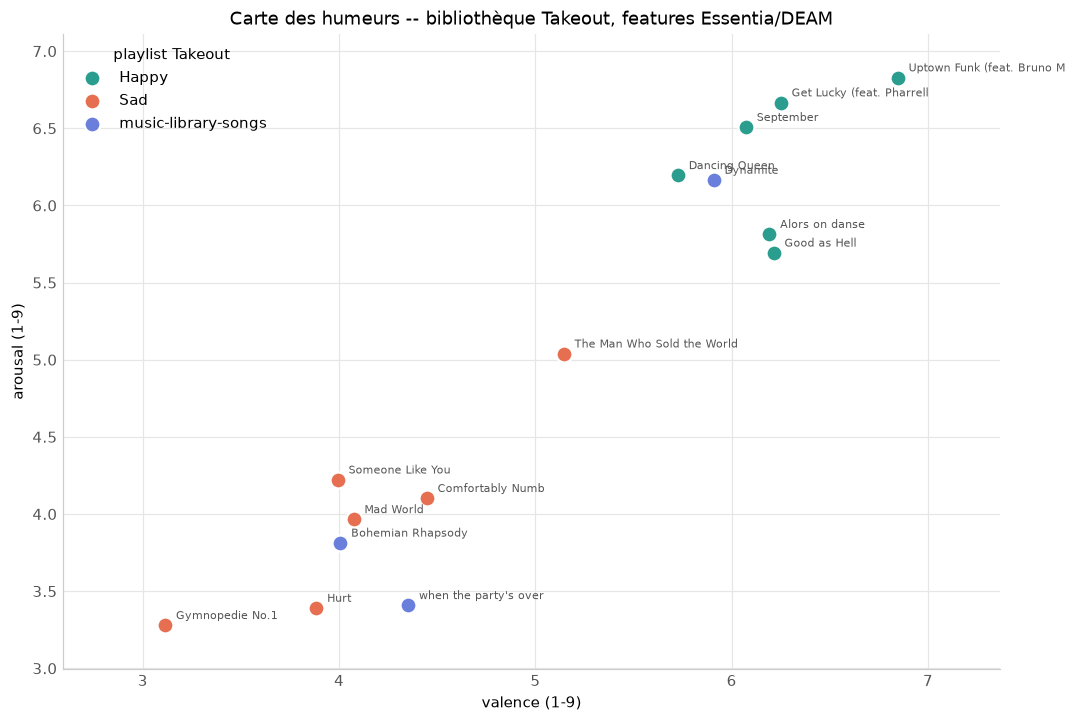

In [9]:
def recessive_axes(ax):
    ax.grid(color="#e6e6e6", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#cccccc")
    ax.tick_params(colors="#555555", length=0)

fig, ax = plt.subplots(figsize=(11, 7.5))
for playlist, grp in feat.groupby("playlist"):
    ax.scatter(grp["valence"], grp["arousal"], s=110, color=PALETTE.get(playlist, "#888888"),
               label=playlist, edgecolor="white", linewidth=1.5, zorder=3)
for _, r in feat.iterrows():
    ax.annotate(r["itunes_track"][:26], (r["valence"], r["arousal"]),
                textcoords="offset points", xytext=(7, 4), fontsize=7.5, color="#555555")
ax.margins(x=0.14, y=0.08)
ax.set_xlabel("valence (1-9)")
ax.set_ylabel("arousal (1-9)")
ax.set_title("Carte des humeurs -- bibliothèque Takeout, features Essentia/DEAM")
ax.legend(frameon=False, title="playlist Takeout")
recessive_axes(ax)
plt.show()

## 6. Playlists sans titre : le chemin API YouTube

Certaines playlists YouTube n'exportent qu'un `Video ID`, sans titre ni artiste. Il faut alors
résoudre les ids via l'API YouTube Data v3 (`videos.list`), qui coûte **1 unité par appel et
accepte 50 ids à la fois** : une bibliothèque de 5 000 morceaux se résout pour ~100 unités
sur les 10 000/jour gratuites. Ça ne demande pas YouTube Premium, juste une clé d'API.

⚠️ **Ce chemin n'est pas exercé dans ce notebook** (il faut ta propre clé). La fonction est
livrée dans `takeout_moods.py` mais, contrairement au reste, elle n'a pas été testée ici —
traite-la comme du code à valider, pas comme du code éprouvé.

In [10]:
# resolved = tm.resolve_video_ids(df["video_id"].dropna().tolist(), api_key="TA_CLE_API")
# puis: artiste/titre via tm.split_artist_title(resolved[vid]["raw_title"])

## Ce que cette exécution dit — et ne dit pas

Sur cet échantillon : **87,5 % de matching direct**, 6,2 % à relire, 6,2 % introuvable
(le seul échec étant un groupe que j'ai inventé pour tester le cas, donc le comportement
attendu).

**Ce chiffre ne vaut pas pour ta bibliothèque.** L'échantillon fait 16 morceaux et je l'ai
construit à la main — il contient volontairement des cas durs (accents, coréen, remaster,
live, « - Topic », titre-tout-en-un), mais il est surtout composé de titres très connus,
donc bien couverts par iTunes. Ton taux réel dépendra de ton catalogue : plus il y a
d'électro obscure, de lives, de bootlegs, d'éditions régionales ou de morceaux non
distribués sur iTunes, plus il baissera. **C'est précisément ce que cette exécution est faite
pour mesurer** — branche `TAKEOUT_PATH` sur ton vrai export et lis la ligne `coverage_report`.

**Les leviers si le taux est trop bas :**
1. lire la table `no_result` : souvent une poignée de motifs récurrents à ajouter aux règles
   de nettoyage, qui débloquent des dizaines de morceaux d'un coup ;
2. baisser le seuil et trier à la main via la colonne `score` ;
3. pour ce qui ne sera jamais sur iTunes, se rabattre sur tes propres fichiers audio —
   `fetch_preview()` est la seule fonction à remplacer, tout le reste du pipeline est identique.

**Attention aux limites de débit :** iTunes est agressif sur le rate-limiting. `match_library()`
temporise et réessaie avec backoff, mais sur plusieurs milliers de morceaux, lance-le en tâche
de fond et sauvegarde au fur et à mesure plutôt qu'en une seule passe.